In [7]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from umap import UMAP

In [ ]:
# DATA

data = np.load('data/LEMON_DATA/real_fake.npz')

x_real = torch.from_numpy(data['real']).flatten(1)
x_fake = torch.from_numpy(data['fake']).flatten(1)
x = torch.cat([x_real, x_fake], dim=0).float()

In [ ]:
# PCA

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
)

x_pca = pipe.fit_transform(x.numpy())

g = sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=['real'] * len(x_real) + ['fake'] * len(x_fake),
    palette=['blue', 'red'],
    alpha=0.4,
    s=5,
)
g.set_title('UMAP Projection')
g.set_ylabel('PCA 2')
g.set_xlabel('PCA 1')
# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')

In [4]:
# UMAP
umapper = UMAP()
x_umap = umapper.fit_transform(x.numpy())

/Users/morteza/workspace/YARE-GAN/.pixi/envs/default/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


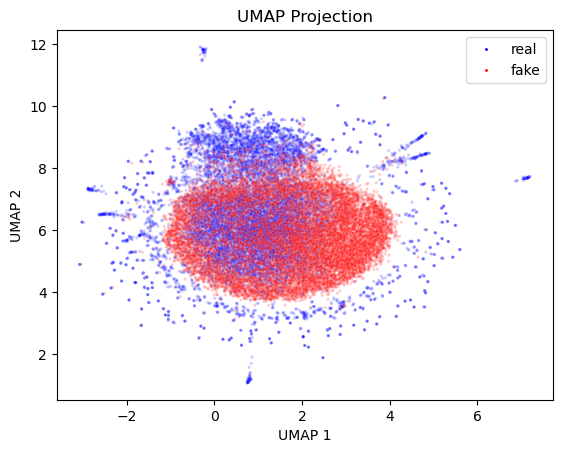

In [6]:
# UMAP Viz

g = sns.scatterplot(
    x=x_umap[:, 0],
    y=x_umap[:, 1],
    hue=['real'] * len(x_real) + ['fake'] * len(x_fake),
    palette=['blue', 'red'],
    alpha=0.2,
    s=5,
)

g.set_title('UMAP Projection')
g.set_ylabel('UMAP 2')
g.set_xlabel('UMAP 1')

# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')

## Visualize subject layer evolution over time

In [2]:
from keras.saving import load_model

def load_subject_weights(model_path):
    model = load_model(model_path, compile=False)
    subject_layer = model.critic.get_layer(model.critic.layers[0].name).module
    return subject_layer.weights.detach().cpu().numpy()

In [3]:
checkpoint_dir = "logs/5/"
epochs = list(range(20, 1300, 20))
weights_over_time = []

for epoch in epochs:
    path = os.path.join(checkpoint_dir, f"20250605_7th_epoch_{epoch}.model.keras")
    weights = load_subject_weights(path)  # shape: (n_subjects, in_ch, out_ch)
    weights_over_time.append(weights)

weights_over_time = np.array(weights_over_time)  # shape: (n_epochs, n_subjects, in_ch, out_ch)

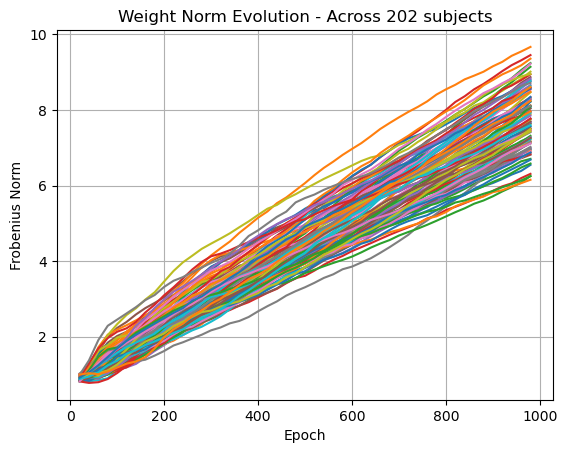

In [ ]:


for subject_id in range(100, 202):
    norms = np.linalg.norm(weights_over_time[:, subject_id], axis=(1, 2))

    plt.plot(epochs, norms)
    plt.title(f"Weight Norm Evolution - Across 202 subjects")
    plt.xlabel("Epoch")
    plt.ylabel("Frobenius Norm")
plt.grid(True)
plt.show()


The constantly progressing weight norm shows that the subject layer is actively learning, with growing norms. also no subject is ignored.

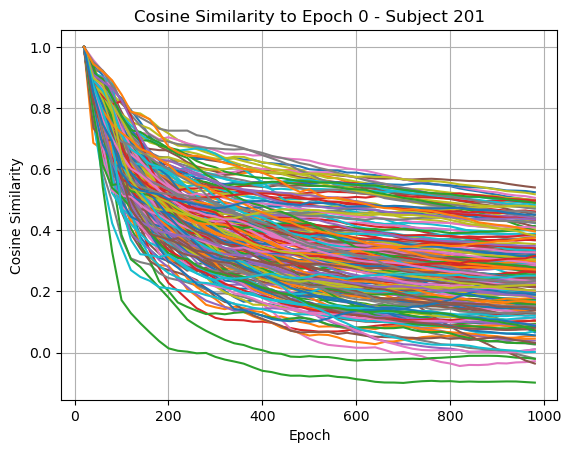

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

for subject_id in range(202):
    w0 = weights_over_time[0, subject_id].reshape(1, -1)

    cos_sims = [cosine_similarity(w0, w.reshape(1, -1))[0, 0]
                for w in weights_over_time[:, subject_id]]

    plt.plot(epochs, cos_sims)
    plt.title(f"Cosine Similarity to Epoch 0 - Across 202 subjects")
    plt.xlabel("Epoch")
    plt.ylabel("Cosine Similarity")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import xarray as xr
demographics = pd.read_csv('data/LEMON_DATA/Demographics.csv')
EEG = xr.open_dataarray('data/LEMON_DATA/EC_ch-8_sf-128.nc5', engine='h5netcdf')
sub_ids = list(EEG.subject.values)
demographics['age_group'] = demographics['Age'].apply(lambda x: 'young' if x=='20-25' or x=='25-30' else 'old')
gender = demographics.set_index('ID').loc[sub_ids, 'Gender_ 1=female_2=male'].values

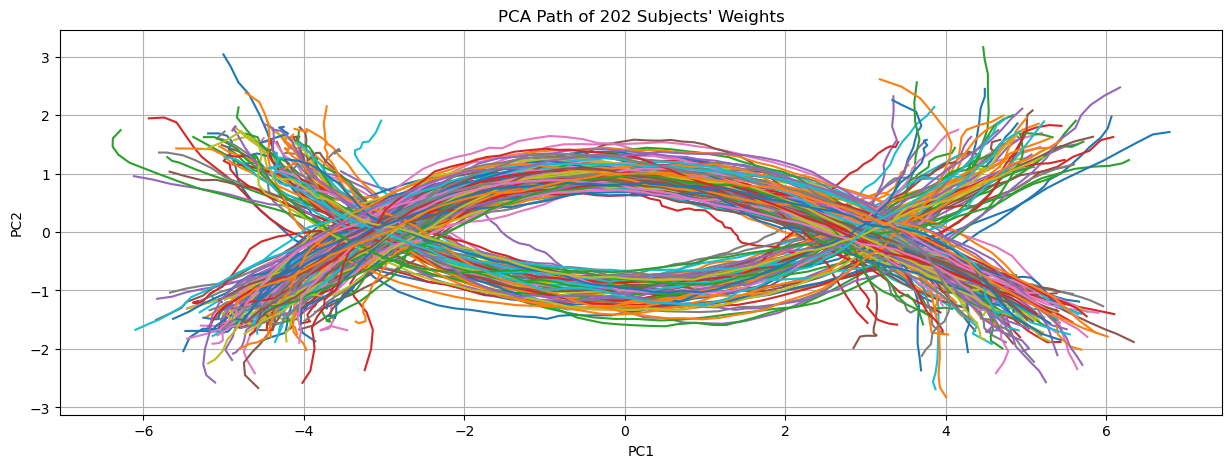

In [ ]:
from sklearn.decomposition import PCA
COLOR_CODE = False
ANNOT = False

plt.figure(figsize=(15, 5))

for subject_id in range(202):
    subject_weights = weights_over_time[:, subject_id].reshape(len(epochs), -1)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(subject_weights)

    if COLOR_CODE:
        if gender[subject_id] == 1:
            color = 'red'
        if gender[subject_id] == 0:
            color = 'blue'
        plt.plot(coords[:, 0], coords[:, 1], color=color)
    else:
        plt.plot(coords[:, 0], coords[:, 1])
    
    if ANNOT:
        for i, epoch in enumerate(epochs):
            plt.annotate(str(epoch), (coords[i, 0], coords[i, 1]), fontsize=8)
    
    plt.title(f"PCA Path of 202 Subjects' Weights")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
# plt.legend()
plt.grid(True)
plt.show()


This interesting decomposed components hints that there's a latent structure — possibly two main subject groups or adaptation strategies. 